In [1]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


RESUME_TRAINING = True
VRAM_FRACTION   = 1.0


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(VRAM_FRACTION, device=0)
    print(f'Using device: {device}  |  VRAM cap: {VRAM_FRACTION*100:.0f}%')
else:
    print('Using device: cpu')

DATA_ROOT  = os.path.join(os.getcwd(), 'data')
MODEL_ROOT = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_ROOT, exist_ok=True)


Using device: cuda  |  VRAM cap: 100%


In [3]:
from helper_functions.utils import PersonReIDDataset

dataset_PersonReID_path = os.path.join(DATA_ROOT, "Market-1501-v15.09.15")

dataset_PersonReID_train = PersonReIDDataset(os.path.join(dataset_PersonReID_path, "bounding_box_train"))
dataset_PersonReID_test  = PersonReIDDataset(os.path.join(dataset_PersonReID_path, "bounding_box_test"))

In [4]:
all_sequences_train = [seq for person_data in dataset_PersonReID_train.sequences_by_person.values()
                           for cam_data in person_data.values()
                           for seq in cam_data]

all_sequences_test  = [seq for person_data in dataset_PersonReID_test.sequences_by_person.values()
                           for cam_data in person_data.values()
                           for seq in cam_data]

print(f"Train sequences: {len(all_sequences_train)}")
print(f"Test sequences:  {len(all_sequences_test)}")

Train sequences: 3444
Test sequences:  4098


In [5]:
import torchvision.transforms as T
from torch.utils.data import Sampler

MAX_SEQ_LEN = 8
P, K = 12, 4

train_transform = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(),
    T.Pad(10),
    T.RandomCrop((256, 128)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

test_transform = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SequenceLabelDataset(Dataset):
    def __init__(self, sequences_by_person, transform, max_seq_len):
        self.transform           = transform
        self.max_seq_len         = max_seq_len
        self.samples             = []
        self.pid_to_indices      = {}
        self.pid_cam_to_indices  = {}

        for pid, cam_data in sequences_by_person.items():
            for cam, seqs in cam_data.items():
                for seq in seqs:
                    i = len(self.samples)
                    self.samples.append((seq, pid))
                    self.pid_to_indices.setdefault(pid, []).append(i)
                    self.pid_cam_to_indices.setdefault(pid, {}).setdefault(cam, []).append(i)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, pid = self.samples[idx]
        paths  = [p.image_path for p in seq[:self.max_seq_len]]
        frames = [self._load(p) for p in paths]
        return torch.stack(frames), len(frames), pid

    def _load(self, path):
        return self.transform(Image.open(path).convert('RGB'))


class PKSampler(Sampler):
    def __init__(self, pid_to_indices, pid_cam_to_indices, P=16, K=4):
        self.pid_to_indices     = pid_to_indices
        self.pid_cam_to_indices = pid_cam_to_indices
        self.P = P
        self.K = K
        self.pids = [pid for pid, idxs in pid_to_indices.items() if len(idxs) >= 2]

    def _sample_cross_camera(self, pid):
        cam_data = self.pid_cam_to_indices[pid]
        cameras  = list(cam_data.keys())
        if len(cameras) == 1:
            return random.choices(self.pid_to_indices[pid], k=self.K)
        random.shuffle(cameras)
        cam_cycle = cameras * (self.K // len(cameras) + 1)
        return [random.choice(cam_data[cam]) for cam in cam_cycle[:self.K]]

    def __iter__(self):
        pids = self.pids.copy()
        random.shuffle(pids)
        for i in range(0, len(pids) - self.P + 1, self.P):
            batch_pids = pids[i : i + self.P]
            batch = []
            for pid in batch_pids:
                batch.extend(self._sample_cross_camera(pid))
            yield batch

    def __len__(self):
        return len(self.pids) // self.P


def sequence_label_collate(batch):
    imgs_list, lengths, pids = zip(*batch)
    max_t = max(lengths)
    C, H, W = imgs_list[0].shape[1:]
    padded = torch.zeros(len(imgs_list), max_t, C, H, W)
    for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
        padded[i, :t] = imgs
    return padded, torch.tensor(lengths, dtype=torch.long), torch.tensor(pids, dtype=torch.long)


In [6]:
train_dataset = SequenceLabelDataset(
    dataset_PersonReID_train.sequences_by_person,
    transform=train_transform,
    max_seq_len=MAX_SEQ_LEN
)

sampler = PKSampler(train_dataset.pid_to_indices,
                    train_dataset.pid_cam_to_indices, P=P, K=K)

print(f"Train sequences: {len(train_dataset)}")
print(f"Persons with >=2 seqs: {len(sampler.pids)}")
print(f"Steps per epoch: {len(sampler)}")

train_loader = DataLoader(
    train_dataset,
    batch_sampler=sampler,
    collate_fn=sequence_label_collate,
    pin_memory=True
)


Train sequences: 3444
Persons with >=2 seqs: 679
Steps per epoch: 56


In [7]:
from helper_functions.model import ImprovedSeqToSeqReIDModel, CombinedReIDLoss

all_train_pids = sorted(dataset_PersonReID_train.sequences_by_person.keys())
pid_to_cls     = {pid: i for i, pid in enumerate(all_train_pids)}
NUM_CLASSES    = len(all_train_pids)
print(f"Number of training identities: {NUM_CLASSES}")

model = ImprovedSeqToSeqReIDModel(
    embedding_dim=512,
    rnn_hidden=512,
    num_classes=NUM_CLASSES
).to(device)

vit_base_lr = 5e-6
decay       = 0.75

param_groups = []

param_groups.append({
    "params": list(model.encoder.vit.patch_embed.parameters()) +
              [model.encoder.vit.pos_embed, model.encoder.vit.cls_token],
    "lr": vit_base_lr * (decay ** 12)
})

for i, block in enumerate(model.encoder.vit.blocks):
    lr = vit_base_lr * (decay ** (11 - i))
    param_groups.append({"params": list(block.parameters()), "lr": lr})

param_groups.append({
    "params": list(model.encoder.vit.norm.parameters()),
    "lr": vit_base_lr
})

head_lr = 5e-5
head_params = (
    list(model.encoder.global_proj.parameters()) +
    list(model.encoder.local_proj_2.parameters()) +
    list(model.encoder.local_proj_4.parameters()) +
    list(model.encoder.local_proj_8.parameters()) +
    list(model.encoder.temporal_tf.parameters()) +
    list(model.encoder.rnn.parameters()) +
    list(model.encoder.attention.parameters()) +
    list(model.encoder.embed_head.parameters()) +
    (list(model.classifier.parameters()) if model.classifier is not None else [])
)
param_groups.append({"params": head_params, "lr": head_lr})

WARMUP_EPOCHS = 5
optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-3, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-8, verbose=True
)
scaler    = torch.amp.GradScaler("cuda")
criterion = CombinedReIDLoss(margin=0.3, circle_m=0.25, circle_gamma=80,
                              lambda_circle=0.2, lambda_stripe=0.3,
                              am_scale=30.0, am_margin=0.35).to(device)

if RESUME_TRAINING:
    for ckpt in ["latest_model_market1501.pth", "best_model_market1501.pth"]:
        ckpt_path = os.path.join(MODEL_ROOT, ckpt)
        if os.path.exists(ckpt_path):
            model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
            print(f"Resumed from {ckpt}")
            break
    else:
        print("WARNING: RESUME_TRAINING=True but no checkpoint found. Starting fresh.")
else:
    print("Starting from scratch.")


c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of training identities: 741


c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Resumed from latest_model_market1501.pth


In [8]:
def train_epoch(model, loader, optimizer, scaler, device, pid_to_cls, criterion):
    model.train()
    total_loss = 0.0
    comp_sums  = {"id_loss": 0.0, "triplet_loss": 0.0,
                  "circle_loss": 0.0, "stripe_loss": 0.0}
    n = 0

    for imgs, lengths, pids in tqdm(loader, desc="Train"):
        imgs = imgs.to(device)
        pids = pids.to(device)
        cls_labels = torch.tensor([pid_to_cls[p.item()] for p in pids],
                                   dtype=torch.long, device=device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            embeddings, logits, stripe_feats = model(imgs, lengths)
            loss, loss_dict = criterion(embeddings, cls_labels, logits,
                                        stripe_feats=stripe_feats, lengths=lengths)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        for k in comp_sums:
            v = loss_dict[k]
            comp_sums[k] += v.item() if hasattr(v, "item") else float(v)
        n += 1

    avg_total = total_loss / n if n > 0 else 0.0
    avg_comps = {k: v / n for k, v in comp_sums.items()} if n > 0 else comp_sums
    return avg_total, avg_comps

In [9]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import gc
import re

_CAM_RE = re.compile(r"c(\d+)")

def _cam_int(cam_str):
    m = _CAM_RE.match(cam_str)
    return int(m.group(1)) if m else -1


def encode_sequences(sequences, model, transform, device,
                      max_seq_len=None, batch_size=32, flip_tta=False):
    model.eval()

    def seq_len(seq):
        s = seq if max_seq_len is None else seq[:max_seq_len]
        return len(s)

    sequences = sorted(sequences, key=seq_len)
    all_embs, all_pids, all_cams = [], [], []

    flip = T.RandomHorizontalFlip(p=1.0)

    def load_seq(seq, flipped=False):
        frames_to_use = seq if max_seq_len is None else seq[:max_seq_len]
        frames = []
        for p in frames_to_use:
            img = Image.open(p.image_path).convert("RGB")
            if flipped:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(transform(img))
        return torch.stack(frames), len(frames), seq[0].person_id, _cam_int(seq[0].camera_id)

    def run_batch(batch_seqs, flipped=False):
        results = [load_seq(s, flipped) for s in batch_seqs]
        imgs_list, lengths, pids, cams = zip(*results)
        max_t = max(lengths)
        C, H, W = imgs_list[0].shape[1:]
        padded = torch.zeros(len(imgs_list), max_t, C, H, W)
        for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
            padded[i, :t] = imgs
        lengths_t = torch.tensor(lengths, dtype=torch.long)
        with torch.amp.autocast("cuda"):
            embs = model(padded.to(device), lengths_t)
        return embs.cpu().float(), pids, cams

    with torch.no_grad():
        for start in tqdm(range(0, len(sequences), batch_size), desc="Encoding"):
            batch_seqs = sequences[start : start + batch_size]
            embs, pids, cams = run_batch(batch_seqs, flipped=False)
            if flip_tta:
                embs_flip, _, _ = run_batch(batch_seqs, flipped=True)
                import torch.nn.functional as F
                embs = F.normalize((embs + embs_flip) / 2, dim=1)
            all_embs.append(embs.numpy())
            all_pids.extend(pids)
            all_cams.extend(cams)

    return (np.concatenate(all_embs, axis=0),
            np.array(all_pids),
            np.array(all_cams))


def _score_with_junk(sorted_idx, q_pids, q_cams, g_pids, g_cams, max_rank=20):
    cmc = np.zeros(max_rank)
    aps = []
    valid = 0
    for i in range(len(q_pids)):
        order = sorted_idx[i]
        g_pid_i = g_pids[order]
        g_cam_i = g_cams[order]

        junk = (g_pid_i == 0) | (g_pid_i == -1) | \
               ((g_pid_i == q_pids[i]) & (g_cam_i == q_cams[i]))
        keep = ~junk
        g_pid_i = g_pid_i[keep]

        match = g_pid_i == q_pids[i]
        if match.sum() == 0:
            continue
        valid += 1

        for r in range(max_rank):
            if match[:r + 1].any():
                cmc[r:] += 1
                break

        cum  = np.cumsum(match)
        prec = cum / np.arange(1, len(match) + 1)
        aps.append(prec[match].mean())

    if valid == 0:
        return 0.0, 0.0, np.zeros(max_rank)
    return float(cmc[0] / valid), float(np.mean(aps)), cmc / valid


def evaluate(query_embs, query_pids, query_cams, gallery_embs, gallery_pids, gallery_cams):
    sim        = cos_sim(query_embs, gallery_embs)
    sorted_idx = np.argsort(-sim, axis=1)
    rank1, mAP, _ = _score_with_junk(sorted_idx, query_pids, query_cams,
                                     gallery_pids, gallery_cams)
    return rank1, mAP


In [10]:
from helper_functions.utils import PersonReIDDataset

query_base   = PersonReIDDataset(os.path.join(dataset_PersonReID_path, "query"),             min_seq_len=1)
gallery_base = PersonReIDDataset(os.path.join(dataset_PersonReID_path, "bounding_box_test"), min_seq_len=1,
                                 keep_distractors=True)

def _flatten_seqs(base_dataset):
    seqs = []
    for pid, cams in base_dataset.sequences_by_person.items():
        for cam, seq_list in cams.items():
            seqs.extend(seq_list)
    return seqs

query_seqs_official   = _flatten_seqs(query_base)
gallery_seqs_official = _flatten_seqs(gallery_base)

print(f"Official split  -- Query: {len(query_seqs_official)}  Gallery: {len(gallery_seqs_official)}")

query_seqs_seq, gallery_seqs_seq = [], []

for pid, cam_data in gallery_base.sequences_by_person.items():
    if pid <= 0:
        continue
    cameras = list(cam_data.keys())
    if len(cameras) < 2:
        for seqs in cam_data.values():
            gallery_seqs_seq.extend(seqs)
        continue
    query_cam = cameras[0]
    for cam, seqs in cam_data.items():
        if cam == query_cam:
            query_seqs_seq.append(seqs[0])
        else:
            gallery_seqs_seq.extend(seqs)

print(f"Sequence split  -- Query: {len(query_seqs_seq)}  Gallery: {len(gallery_seqs_seq)}")


Official split  -- Query: 3368  Gallery: 11783
Sequence split  -- Query: 750  Gallery: 6060


In [11]:
NUM_EPOCHS = 100
PATIENCE   = 15

BEST_CKPT   = os.path.join(MODEL_ROOT, 'best_model_market1501.pth')
LATEST_CKPT = os.path.join(MODEL_ROOT, 'latest_model_market1501.pth')

best_rank1       = 0.0
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss, loss_comps = train_epoch(model, train_loader, optimizer, scaler,
                                         device, pid_to_cls, criterion)

    torch.save(model.state_dict(), LATEST_CKPT)

    gc.collect()
    q_embs, q_pids, q_cams = encode_sequences(query_seqs_official,   model, test_transform, device, flip_tta=True)
    g_embs, g_pids, g_cams = encode_sequences(gallery_seqs_official, model, test_transform, device,
                                               max_seq_len=MAX_SEQ_LEN, flip_tta=True)
    model.train()
    gc.collect()
    rank1, mAP = evaluate(q_embs, q_pids, q_cams, g_embs, g_pids, g_cams)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  '
          f'loss={train_loss:.4f}  '
          f'id={loss_comps["id_loss"]:.4f}  '
          f'tri={loss_comps["triplet_loss"]:.4f}  '
          f'cir={loss_comps["circle_loss"] * criterion.lambda_circle:.4f}  '
          f'stripe={loss_comps["stripe_loss"] * criterion.lambda_stripe:.4f}  '
          f'Rank-1={rank1:.4f}  mAP={mAP:.4f}')

    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        scheduler.step(rank1)

    if rank1 > best_rank1:
        best_rank1       = rank1
        patience_counter = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print('  --> Saved best model')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print('Early stopping.')
            break

print(f'Best Rank-1: {best_rank1:.4f}')


Encoding: 100%|██████████| 369/369 [01:42<00:00,  3.61it/s]


Epoch [1/100]  loss=6.1362  id=4.6992  tri=0.9925  cir=0.4409  stripe=0.0036  Rank-1=0.8982  mAP=0.8055
  --> Saved best model


Encoding: 100%|██████████| 369/369 [01:24<00:00,  4.37it/s]


Epoch [2/100]  loss=6.0115  id=4.5910  tri=0.9894  cir=0.4276  stripe=0.0035  Rank-1=0.9011  mAP=0.8100
  --> Saved best model


Encoding: 100%|██████████| 369/369 [01:25<00:00,  4.34it/s]


...

Epoch [36/100]  loss=2.0031  id=1.1693  tri=0.7940  cir=0.0387  stripe=0.0010  Rank-1=0.9103  mAP=0.8293


Encoding: 100%|██████████| 369/369 [01:24<00:00,  4.37it/s]


Epoch [37/100]  loss=1.9628  id=1.1535  tri=0.7837  cir=0.0247  stripe=0.0009  Rank-1=0.9103  mAP=0.8299


Encoding: 100%|██████████| 369/369 [01:25<00:00,  4.34it/s]


Epoch [38/100]  loss=1.9669  id=1.1589  tri=0.7808  cir=0.0263  stripe=0.0009  Rank-1=0.9124  mAP=0.8304
Early stopping.
Best Rank-1: 0.9175


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

model.load_state_dict(torch.load(
    os.path.join(MODEL_ROOT, "best_model_market1501.pth"),
    map_location=device, weights_only=True
))

def re_ranking(q_embs, g_embs, k1=20, k2=6, lambda_value=0.3):
    feat = np.concatenate([q_embs, g_embs], axis=0)
    n_q  = len(q_embs)
    n    = len(feat)
    dist = 2 - 2 * (feat @ feat.T).clip(-1, 1)
    initial_rank = np.argsort(dist, axis=1)
    V = np.zeros_like(dist)
    for i in range(n):
        forward = set(initial_rank[i, 1:k1+1])
        R_i = [j for j in forward if i in set(initial_rank[j, 1:k1+1])]
        R_i_exp = list(R_i)
        for q in R_i:
            R_q = set(initial_rank[q, 1:int(k1/2)+1])
            if len(R_q & set(R_i)) / len(R_q) >= 2/3:
                R_i_exp += list(R_q)
        R_i_exp = list(set(R_i_exp))
        w = np.exp(-dist[i, R_i_exp])
        w /= w.sum() + 1e-12
        V[i, R_i_exp] = w
    if k2 != 1:
        V_qe = np.zeros_like(V)
        for i in range(n):
            V_qe[i] = V[initial_rank[i, :k2]].mean(axis=0)
        V = V_qe
    jaccard = np.zeros((n_q, n - n_q))
    for i in range(n_q):
        for j in range(n_q, n):
            inter = np.minimum(V[i], V[j]).sum()
            union = np.maximum(V[i], V[j]).sum()
            jaccard[i, j - n_q] = 1 - inter / (union + 1e-12)
    orig_dist = dist[:n_q, n_q:]
    return jaccard * (1 - lambda_value) + orig_dist * lambda_value


def evaluate_rerank(q_embs, q_pids, q_cams, g_embs, g_pids, g_cams,
                    k1=20, k2=6, lambda_value=0.3):
    dist = re_ranking(q_embs, g_embs, k1=k1, k2=k2, lambda_value=lambda_value)
    sorted_idx = np.argsort(dist, axis=1)
    rank1, mAP, _ = _score_with_junk(sorted_idx, q_pids, q_cams, g_pids, g_cams)
    return rank1, mAP


MAX_RANK = 20

print("=== Official Market-1501 split (query/ + bounding_box_test/) ===")
q_embs_off, q_pids_off, q_cams_off = encode_sequences(query_seqs_official,   model, test_transform, device, flip_tta=True)
g_embs_off, g_pids_off, g_cams_off = encode_sequences(gallery_seqs_official, model, test_transform, device,
                                                       max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1_off, mAP_off = evaluate(q_embs_off, q_pids_off, q_cams_off, g_embs_off, g_pids_off, g_cams_off)
rank1_rr_off, mAP_rr_off = evaluate_rerank(q_embs_off, q_pids_off, q_cams_off,
                                           g_embs_off, g_pids_off, g_cams_off)
print(f"Without re-ranking: Rank-1={rank1_off:.4f}  mAP={mAP_off:.4f}")
print(f"With    re-ranking: Rank-1={rank1_rr_off:.4f}  mAP={mAP_rr_off:.4f}")

sim_off        = cos_sim(q_embs_off, g_embs_off)
sorted_off     = np.argsort(-sim_off, axis=1)
_, _, cmc_off  = _score_with_junk(sorted_off, q_pids_off, q_cams_off,
                                  g_pids_off, g_cams_off, max_rank=MAX_RANK)
print(f"CMC: Rank-1={cmc_off[0]:.4f}  Rank-5={cmc_off[4]:.4f}  Rank-10={cmc_off[9]:.4f}  Rank-20={cmc_off[19]:.4f}")

gc.collect()
torch.cuda.empty_cache()

print("")
print("=== Sequence-based cross-camera split (from bounding_box_test/) ===")
q_embs_seq, q_pids_seq, q_cams_seq = encode_sequences(query_seqs_seq,   model, test_transform, device, flip_tta=True)
g_embs_seq, g_pids_seq, g_cams_seq = encode_sequences(gallery_seqs_seq, model, test_transform, device,
                                                       max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1_seq, mAP_seq = evaluate(q_embs_seq, q_pids_seq, q_cams_seq, g_embs_seq, g_pids_seq, g_cams_seq)
rank1_rr_seq, mAP_rr_seq = evaluate_rerank(q_embs_seq, q_pids_seq, q_cams_seq,
                                           g_embs_seq, g_pids_seq, g_cams_seq)
print(f"Without re-ranking: Rank-1={rank1_seq:.4f}  mAP={mAP_seq:.4f}")
print(f"With    re-ranking: Rank-1={rank1_rr_seq:.4f}  mAP={mAP_rr_seq:.4f}")

sim_seq        = cos_sim(q_embs_seq, g_embs_seq)
sorted_seq     = np.argsort(-sim_seq, axis=1)
_, _, cmc_seq  = _score_with_junk(sorted_seq, q_pids_seq, q_cams_seq,
                                  g_pids_seq, g_cams_seq, max_rank=MAX_RANK)
print(f"CMC: Rank-1={cmc_seq[0]:.4f}  Rank-5={cmc_seq[4]:.4f}  Rank-10={cmc_seq[9]:.4f}  Rank-20={cmc_seq[19]:.4f}")

gc.collect()
torch.cuda.empty_cache()




=== Official Market-1501 split (query/ + bounding_box_test/) ===


Encoding: 100%|██████████| 369/369 [01:23<00:00,  4.43it/s]


KeyboardInterrupt: 

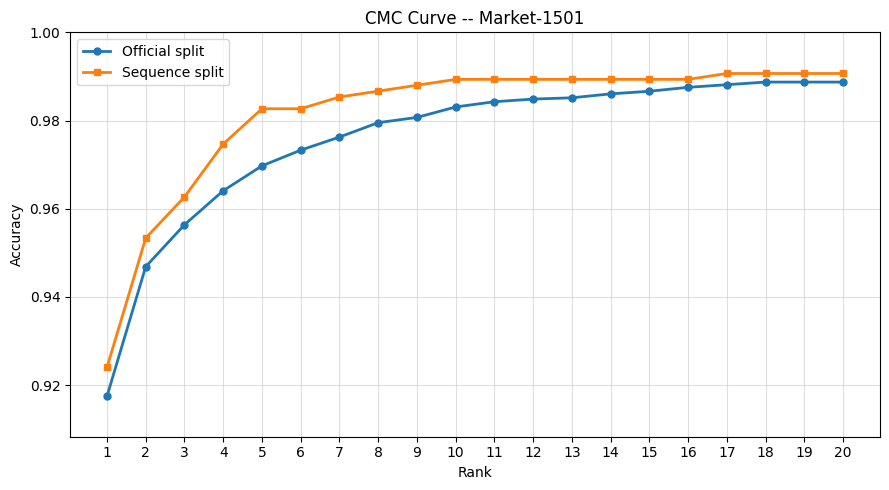

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, MAX_RANK+1), cmc_off, marker='o', linewidth=2, markersize=5, label='Official split')
plt.plot(range(1, MAX_RANK+1), cmc_seq, marker='s', linewidth=2, markersize=5, label='Sequence split')
plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('CMC Curve -- Market-1501')
plt.xticks(range(1, MAX_RANK+1))
plt.ylim(0.99 * min(min(cmc_off),min(cmc_seq)), 1)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('market1501_cmc.png', dpi=150)
plt.show()

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

model.load_state_dict(torch.load(
    os.path.join(MODEL_ROOT, "best_model_market1501.pth"),
    map_location=device, weights_only=True
))

def re_ranking(q_embs, g_embs, k1=20, k2=6, lambda_value=0.3):
    feat = np.concatenate([q_embs, g_embs], axis=0)
    n_q  = len(q_embs)
    n    = len(feat)
    dist = 2 - 2 * (feat @ feat.T).clip(-1, 1)
    initial_rank = np.argsort(dist, axis=1)
    V = np.zeros_like(dist)
    for i in range(n):
        forward = set(initial_rank[i, 1:k1+1])
        R_i = [j for j in forward if i in set(initial_rank[j, 1:k1+1])]
        R_i_exp = list(R_i)
        for q in R_i:
            R_q = set(initial_rank[q, 1:int(k1/2)+1])
            if len(R_q & set(R_i)) / len(R_q) >= 2/3:
                R_i_exp += list(R_q)
        R_i_exp = list(set(R_i_exp))
        w = np.exp(-dist[i, R_i_exp])
        w /= w.sum() + 1e-12
        V[i, R_i_exp] = w
    if k2 != 1:
        V_qe = np.zeros_like(V)
        for i in range(n):
            V_qe[i] = V[initial_rank[i, :k2]].mean(axis=0)
        V = V_qe
    jaccard = np.zeros((n_q, n - n_q))
    for i in range(n_q):
        for j in range(n_q, n):
            inter = np.minimum(V[i], V[j]).sum()
            union = np.maximum(V[i], V[j]).sum()
            jaccard[i, j - n_q] = 1 - inter / (union + 1e-12)
    orig_dist = dist[:n_q, n_q:]
    return jaccard * (1 - lambda_value) + orig_dist * lambda_value

def evaluate_rerank(q_embs, q_pids, g_embs, g_pids, k1=20, k2=6, lambda_value=0.3):
    dist = re_ranking(q_embs, g_embs, k1=k1, k2=k2, lambda_value=lambda_value)
    sorted_idx = np.argsort(dist, axis=1)
    rank1_rr = np.mean(g_pids[sorted_idx[:, 0]] == q_pids)
    aps = []
    for i in range(len(q_pids)):
        relevant = g_pids[sorted_idx[i]] == q_pids[i]
        if relevant.sum() == 0:
            continue
        cum  = np.cumsum(relevant)
        prec = cum / (np.arange(1, len(relevant) + 1))
        aps.append(prec[relevant].mean())
    return rank1_rr, float(np.mean(aps)) if aps else 0.0

print("=== Official Market-1501 split (query/ + bounding_box_test/) ===")
q_embs_off, q_pids_off = encode_sequences(query_seqs_official,   model, test_transform, device, flip_tta=True)
g_embs_off, g_pids_off = encode_sequences(gallery_seqs_official, model, test_transform, device,
                                           max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1_off, mAP_off = evaluate(q_embs_off, q_pids_off, g_embs_off, g_pids_off)
rank1_rr_off, mAP_rr_off = evaluate_rerank(q_embs_off, q_pids_off, g_embs_off, g_pids_off)
print(f"Without re-ranking: Rank-1={rank1_off:.4f}  mAP={mAP_off:.4f}")
print(f"With    re-ranking: Rank-1={rank1_rr_off:.4f}  mAP={mAP_rr_off:.4f}")

sim_off        = cos_sim(q_embs_off, g_embs_off)
sorted_off     = np.argsort(-sim_off, axis=1)
MAX_RANK = 20
cmc_off = np.zeros(MAX_RANK)
for i in range(len(q_pids_off)):
    matches = g_pids_off[sorted_off[i]] == q_pids_off[i]
    for r in range(MAX_RANK):
        if matches[:r+1].any():
            cmc_off[r:] += 1
            break
cmc_off /= len(q_pids_off)
print(f"CMC: Rank-1={cmc_off[0]:.4f}  Rank-5={cmc_off[4]:.4f}  Rank-10={cmc_off[9]:.4f}  Rank-20={cmc_off[19]:.4f}")

gc.collect()
torch.cuda.empty_cache()

print("")
print("=== Sequence-based cross-camera split (from bounding_box_test/) ===")
q_embs_seq, q_pids_seq = encode_sequences(query_seqs_seq,   model, test_transform, device, flip_tta=True)
g_embs_seq, g_pids_seq = encode_sequences(gallery_seqs_seq, model, test_transform, device,
                                           max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1_seq, mAP_seq = evaluate(q_embs_seq, q_pids_seq, g_embs_seq, g_pids_seq)
rank1_rr_seq, mAP_rr_seq = evaluate_rerank(q_embs_seq, q_pids_seq, g_embs_seq, g_pids_seq)
print(f"Without re-ranking: Rank-1={rank1_seq:.4f}  mAP={mAP_seq:.4f}")
print(f"With    re-ranking: Rank-1={rank1_rr_seq:.4f}  mAP={mAP_rr_seq:.4f}")

sim_seq        = cos_sim(q_embs_seq, g_embs_seq)
sorted_seq     = np.argsort(-sim_seq, axis=1)
cmc_seq = np.zeros(MAX_RANK)
for i in range(len(q_pids_seq)):
    matches = g_pids_seq[sorted_seq[i]] == q_pids_seq[i]
    for r in range(MAX_RANK):
        if matches[:r+1].any():
            cmc_seq[r:] += 1
            break
cmc_seq /= len(q_pids_seq)
print(f"CMC: Rank-1={cmc_seq[0]:.4f}  Rank-5={cmc_seq[4]:.4f}  Rank-10={cmc_seq[9]:.4f}  Rank-20={cmc_seq[19]:.4f}")

gc.collect()
torch.cuda.empty_cache()

plt.figure(figsize=(9, 5))
plt.plot(range(1, MAX_RANK+1), cmc_off, marker='o', linewidth=2, markersize=4, label='Official split')
plt.plot(range(1, MAX_RANK+1), cmc_seq, marker='s', linewidth=2, markersize=4, label='Sequence split')
plt.xlabel('Rank')
plt.ylabel('Identification Rate')
plt.title('CMC Curve -- Market-1501')
plt.xticks(range(1, MAX_RANK+1))
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('market1501_cmc.png', dpi=150)
plt.show()

=== Official Market-1501 split (query/ + bounding_box_test/) ===


Encoding: 100%|██████████| 106/106 [00:14<00:00,  7.31it/s]


ValueError: too many values to unpack (expected 2)

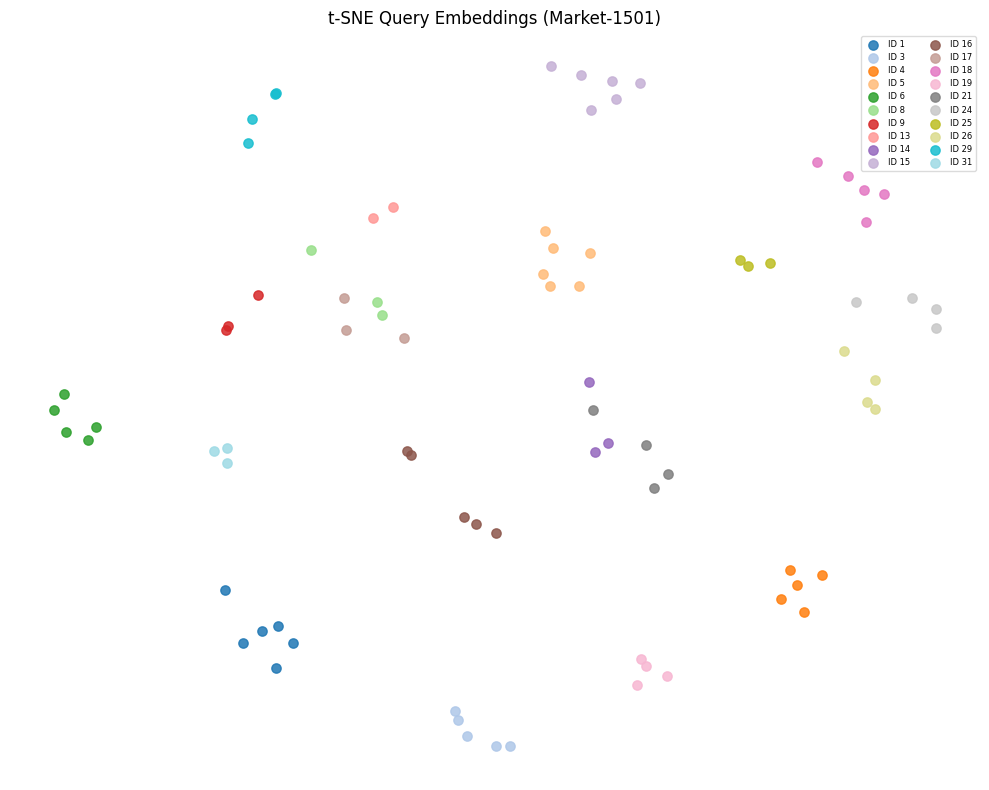

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

N_PERSONS = 20
unique_pids = np.unique(q_pids)
selected_pids = unique_pids[:N_PERSONS]

mask = np.isin(q_pids, selected_pids)
embs_sub = q_embs[mask]
pids_sub  = q_pids[mask]

tsne   = TSNE(n_components=2, perplexity=min(30, len(embs_sub) - 1),
              n_iter_without_progress=1000, random_state=42)
coords = tsne.fit_transform(embs_sub)

colors = cm.tab20(np.linspace(0, 1, N_PERSONS))
pid_color = {pid: colors[i] for i, pid in enumerate(selected_pids)}

plt.figure(figsize=(10, 8))
for pid in selected_pids:
    idx = pids_sub == pid
    plt.scatter(coords[idx, 0], coords[idx, 1],
                color=pid_color[pid], label=f'ID {pid}', s=45, alpha=0.85)

plt.legend(loc='best', fontsize=6, ncol=2, framealpha=0.7)
plt.title('t-SNE Query Embeddings (Market-1501)')
plt.axis('off')
plt.tight_layout()
plt.savefig('market1501_tsne.png', dpi=150)
plt.show()
